In [1]:
from IPython.display import display
from md_Helpers import hot_spike
from md_Helpers import visualization as vh

result = hot_spike.get_or_create_hot_spike(
    n_fcc_cells=80,
    target_rho=0.720,
    kT=0.800,
    source_nsteps=1_000_000,
    source_seed=1,
    radius=3.0,
    injected_energy=700,
    method="velocity_rescale_com",
    nsteps2=980_000,
    dt2=0.005,
    log_period=1_000,
    trajectory_period=1_000,
    random_location=False,
    overwrite=False,
    overwrite_initial=False,
    overwrite_source=False,
    create_source_if_missing=True,
    reject_phase_separated_source=True,
)

Thermalized state exists: checking phase separation.
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_80/rho_0.720/kT_0.800/nsteps_1000000/seed_1/randomization.gsd


Loaded existing hot-spike initial state:
/exp/e961/data/MDsims-data/pnichols/Excitation_States_v3/FCC/n_cells_80/source_kT_0.800/rho_0.720/source_nsteps_1000000/source_seed_1/method_velocity_rescale_com/radius_3.000/energy_700.000/center_box/excitation_initial.gsd


In [3]:
display(vh.animate_hot_spike_xy_slice_trajectory(
    result,
    fraction=0.05,
    stride=25,
    max_frames=20,
    point_size=2,
    alpha=0.7,
    interval=80,
    show_radius=True,
))

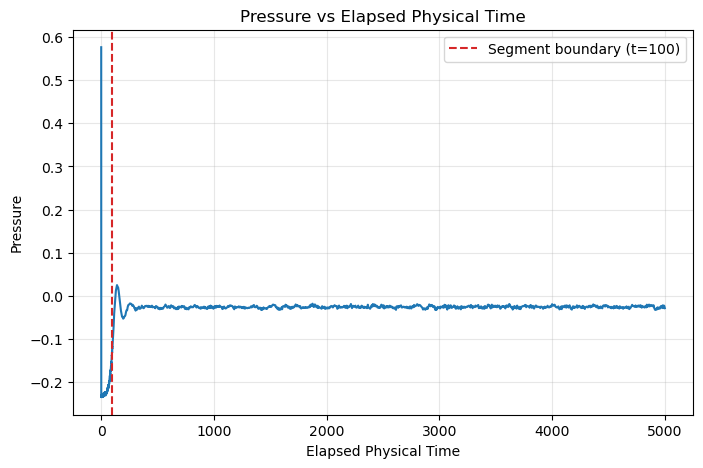

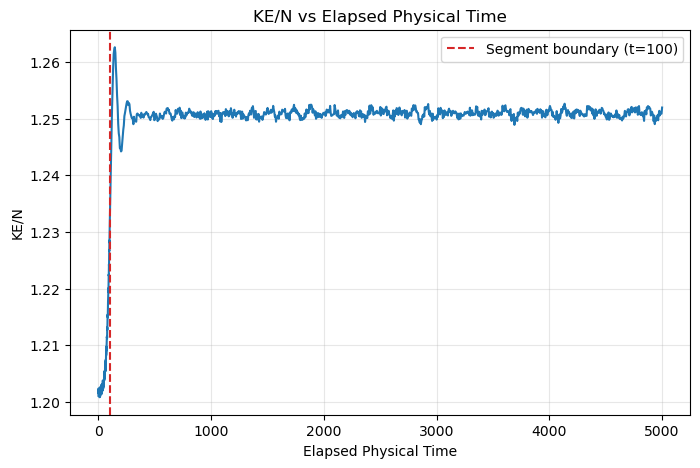

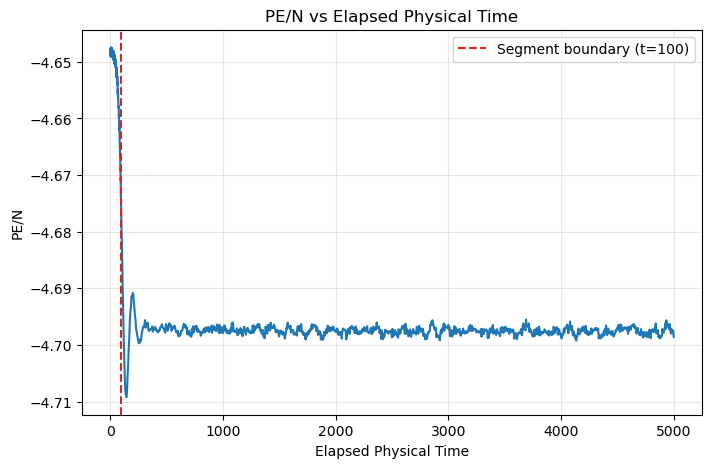

In [2]:
import importlib
from md_Helpers import excitation_evolution
from md_Helpers import visualization as vh

importlib.reload(excitation_evolution)
importlib.reload(vh)

log = excitation_evolution.read_stitched_log(result)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_energy")
vh.plot_log_quantity(log, "potential_energy")

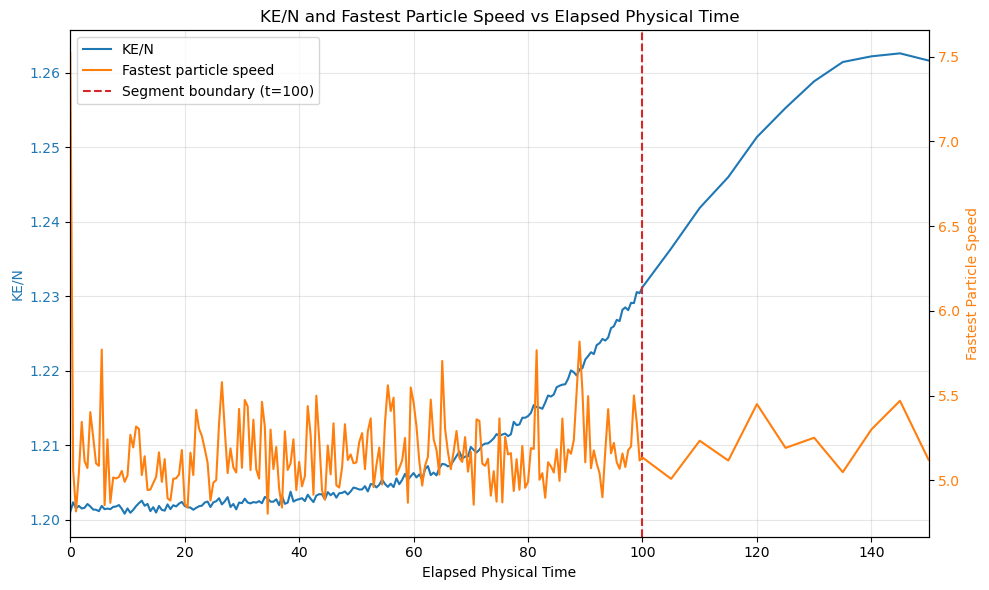

In [15]:
import importlib
from md_Helpers import excitation_evolution
from md_Helpers import visualization as vh

importlib.reload(excitation_evolution)
importlib.reload(vh)

diagnostic = vh.plot_ke_and_fastest_particle_speed(
    result,       # use view_result here if that contains the desired energy
    max_time=150,
)

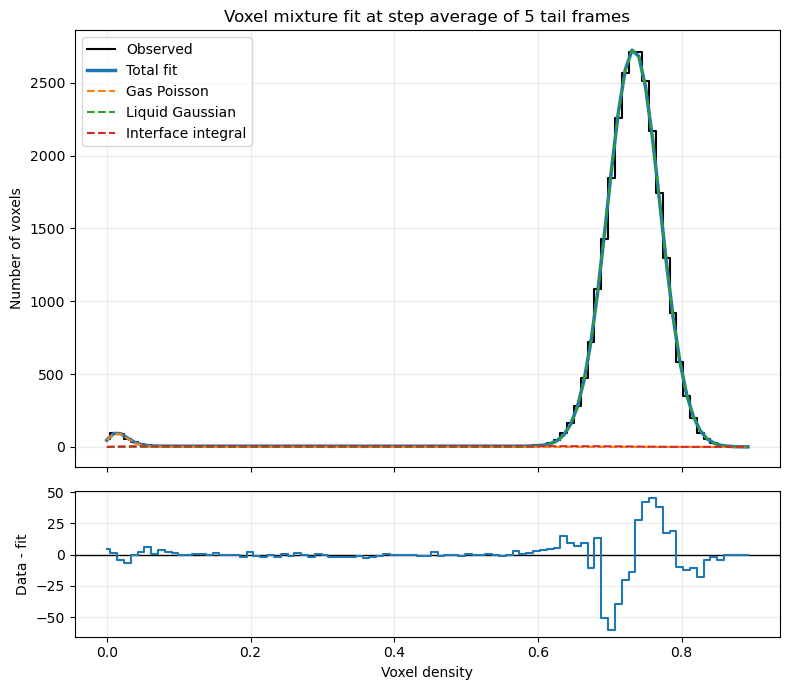

In [16]:
check = vh.fit_and_animate_final_bubble(
    result,
    nbins=30,
    nframes=5,
    skip=5,
    tail_fraction=0.2,
)

In [17]:
from pprint import pprint

# Works for either an initial or evolved hot-spike result
initial = result.get("initial_result", result)
info = initial["creation_info"]

print("Particles scaled:", info["selected_particle_count"])
print("Velocity scale factor:", info["velocity_scale_factor"])

pprint(info, sort_dicts=False)

Particles scaled: 89
Velocity scale factor: 2.750063781688084
{'created_new': False,
 'state_path': '/exp/e961/data/MDsims-data/pnichols/Excitation_States_v3/FCC/n_cells_80/source_kT_0.800/rho_0.720/source_nsteps_1000000/source_seed_1/method_velocity_rescale_com/radius_3.000/energy_700.000/center_box/excitation_initial.gsd',
 'creation_metadata_path': '/exp/e961/data/MDsims-data/pnichols/Excitation_States_v3/FCC/n_cells_80/source_kT_0.800/rho_0.720/source_nsteps_1000000/source_seed_1/method_velocity_rescale_com/radius_3.000/energy_700.000/center_box/excitation_creation.hdf5',
 'N': 2048000,
 'actual_injected_energy': 699.9999999999999,
 'center_of_mass_velocity_preserved': True,
 'energy_dump_method': 'velocity_rescale_com',
 'energy_per_selected_particle': 7.865168539325842,
 'energy_reference': 'direct_input',
 'energy_units': 'reduced_lj',
 'location_seed': 1,
 'location_seed_source': 'source_thermalization_metadata_seed',
 'momentum_conserving': True,
 'periodic_distance': True,
 '